In [2]:
import pandas as pd
import numpy as np
import random
import scipy
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, pearsonr
from scipy import sparse
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.cross_decomposition import CCA
from scipy.sparse.linalg import eigsh, svds, inv
from scipy.linalg import eig, svd
import cv2
csfont = {'fontname':'Times New Roman'}
import matplotlib.font_manager as font_manager
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix, diags, eye
from scipy.spatial import distance_matrix
from sklearn.preprocessing import normalize
import networkx as nx


plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["mathtext.it"] = "Times New Roman:italic"
plt.rcParams["mathtext.bf"] = "Times New Roman:bold"

In [3]:
exec(open("Functions.py").read())

# Line vs. Squere

In [4]:
N = 2000
W = 4
L = 2
H = 1
X1 = np.zeros((N,1))
X2 = np.zeros((N,3))

w = np.random.uniform(0,W,N)
l = np.random.uniform(0,L,N)
h = np.random.uniform(0,H,N)

X1 = w[np.newaxis].T
X2 = np.vstack((w, l, h)).T 


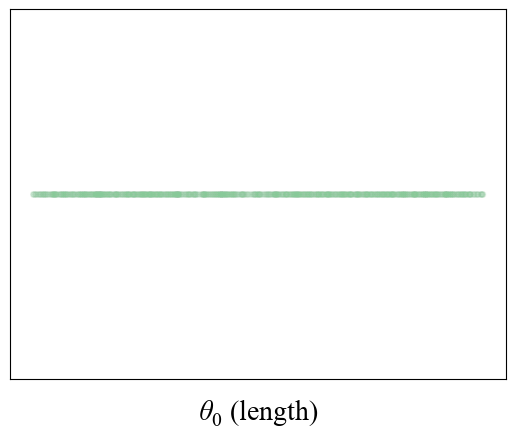

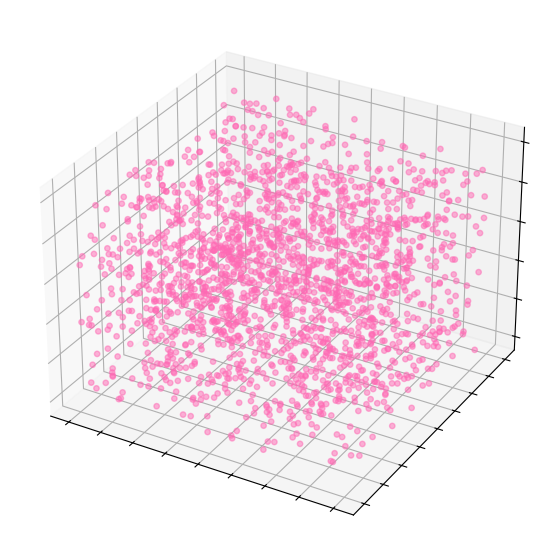

In [5]:

fig, ax = plt.subplots()
ax.scatter(X2[:,0], np.zeros(2000), s = 15, c='#88c999', alpha = 0.05)
ax.set_xlabel(r"$\theta_0$ (length)", fontsize = 20, rotation=0)
# ax.set_ylabel(r"$\theta_1$ (width)", fontsize = 20, rotation=90)
# ax.yaxis.set_label_coords(-.05, .5)
ax.xaxis.set_label_coords(.5, -0.05)
for ax in fig.get_axes():
    ax.tick_params(left = False, right = False , labelleft = False ,labelbottom=False, bottom=False)

plt.savefig("rectangle", dpi = 400)
plt.show()


from mpl_toolkits import mplot3d

# Creating figure
fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")
for ax in fig.get_axes():
#     ax.set(xlabel="$\Theta$",ylabel="$\Psi_B$")
    ax.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)

# Creating plot
ax.scatter3D(X2[:,0], X2[:,1], X2[:,2], c='hotpink', alpha = 0.5, s= 15)
plt.savefig("Cube", dpi = 900)


### Differential vectors:

In [6]:
K1 = Kernel_matrix(X1,250)
K2 = Kernel_matrix(X2,250)
L1, d1, v1 = LG_sym(K1)
L2, d2, v2 = LG_sym(K2)


In [7]:
len(np.where(d1>0.0005)[0])

29

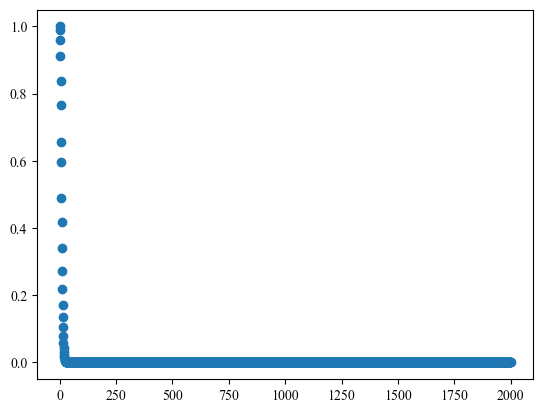

In [8]:
plt.scatter(np.arange(N),d1)

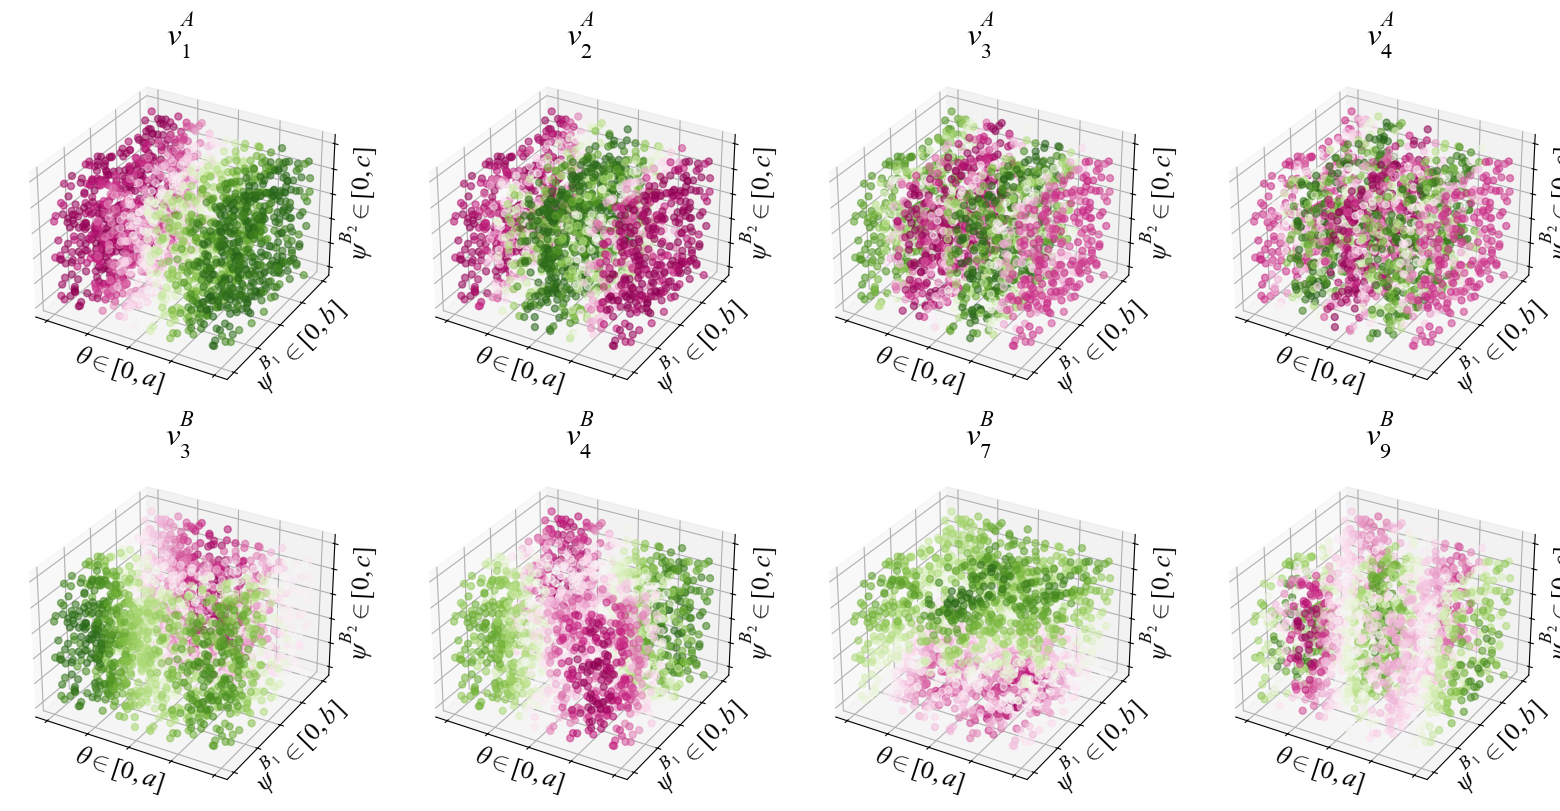

In [14]:
# set up a figure twice as wide as it is tall
# fig = plt.figure(figsize=plt.figaspect(0.55),layout='constrained')
fig = plt.figure(figsize=(16,8), layout='constrained')

#===============
#  First subplot
#===============

ax = fig.add_subplot(2, 4, 1, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = v1[:,1],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ v_1^A$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height


#===============
# Second subplot
#===============

ax = fig.add_subplot(2, 4, 2, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = v1[:,2],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ v_2^A$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height

#===============
# Third subplot
#===============

ax = fig.add_subplot(2, 4, 3, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = v1[:,3],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ v_3^A$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height


#===============
# Fourth subplot
#===============

ax = fig.add_subplot(2, 4, 4, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = v1[:,4],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ v_4^A$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height


#===============
# Fifth subplot
#===============

ax = fig.add_subplot(2, 4, 5, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = v2[:,3],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ v_3^B$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height


#===============
# Sixth subplot
#===============

ax = fig.add_subplot(2, 4, 6, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = v2[:,4],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ v_4^B$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height


#===============
# Seventh subplot
#===============

ax = fig.add_subplot(2, 4, 7, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = v2[:,7],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ v_7^B$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height

#===============
# Eighth subplot
#===============

ax = fig.add_subplot(2, 4, 8, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = v2[:,9],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ v_9^B$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height



# for ax in fig.get_axes():
# #     ax.set(xlabel="$\Theta$",ylabel="$\Psi_B$")
#     ax.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)

# Labels
x_label = r"$\theta \in [0,a]$"
y_label = r"$\psi^{B_1} \in [0,b]$"
z_label = r"$\psi^{B_2} \in [0,c]$"

for ax in fig.get_axes():
    ax.set_xlabel(x_label, fontsize=19, labelpad=-10)
    ax.set_ylabel(y_label, fontsize=19, labelpad=-9)
    ax.set_zlabel(z_label, fontsize=19, labelpad=-9)
   
    # Optional: hide ticks if you want
    ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
    


plt.savefig("3d eigenvectors vs height - LA and LB.pdf", dpi=300) 
plt.show()

In [15]:
Q1, s1, u1 = calc_differential_vec(L2,v1,5,"yes")

Q2, s2, u2 = calc_differential_vec(L1,v2,5, "yes")



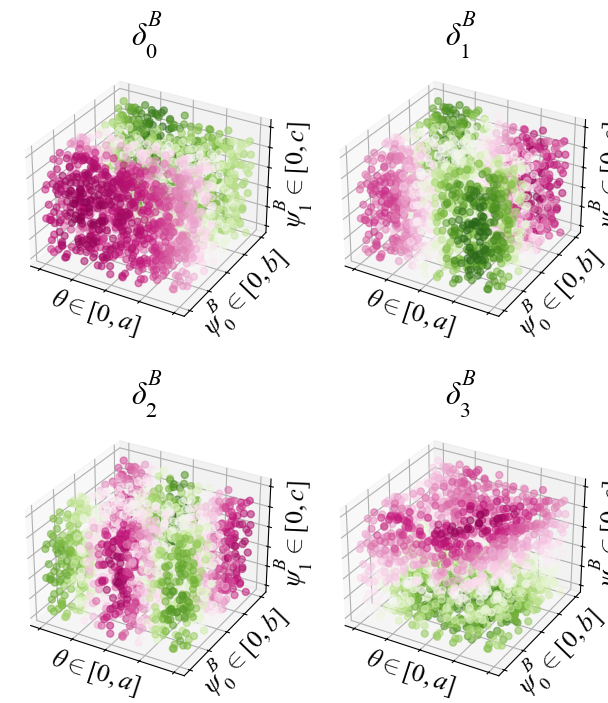

In [68]:
# set up a figure twice as wide as it is tall
# fig = plt.figure(figsize=plt.figaspect(0.55),layout='constrained')
fig = plt.figure(figsize=(7,8))

#===============
#  First subplot
#===============

ax = fig.add_subplot(2, 2, 1, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = u1[:,0],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ \delta^B_0$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height


#===============
# Second subplot
#===============

ax = fig.add_subplot(2, 2, 2, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = u1[:,1],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ \delta^B_1$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height

#===============
# Third subplot
#===============

ax = fig.add_subplot(2,2, 3, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = u1[:,2],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ \delta^B_2$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height


#===============
# Fourth subplot
#===============

ax = fig.add_subplot(2,2, 4, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = u1[:,3],alpha=0.55, cmap='PiYG',s=25)
ax.set_title(r"$ \delta^B_3$",fontsize=23)
ax.title.set_position([0.5, 0.45])  # 0.5 = center, 0.95 = 95% of axes height



# for ax in fig.get_axes():
# #     ax.set(xlabel="$\Theta$",ylabel="$\Psi_B$")
#     ax.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)

# Labels
x_label = r"$\theta \in [0,a]$"
y_label = r"$\psi^B_0 \in [0,b]$"
z_label = r"$\psi^B_1 \in [0,c]$"

for ax in fig.get_axes():
    ax.set_xlabel(x_label, fontsize=19, labelpad=-10)
    ax.set_ylabel(y_label, fontsize=19, labelpad=-9)
    ax.set_zlabel(z_label, fontsize=19, labelpad=-9)
   
    # Optional: hide ticks if you want
    ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

plt.subplots_adjust(left=0.08, right=0.92, 
                    bottom=0.08, top=0.92,
                    wspace=0.15, hspace=0.15)

plt.savefig("3d differentials cube.pdf")
plt.show()

# One method for iteration:

In [34]:
U1 = v1[:,:5]
Qab = U1 @ U1.T
U1 = 0
Qab = Qab@L2@Qab

U2 = v2[:,:5]
Qba = U2 @ U2.T
U2 = 0
Qba = Qba@L1@Qba

s, u_ab = np.linalg.eigh(Qab)#L1@L2+L2@L1
idx_order = np.argsort(s)[::-1]
u_ab = u_ab[:,idx_order]


s2, u_ba = np.linalg.eigh(Qba)
idx_order2 = np.argsort(s2)[::-1]
u_ba = u_ba[:,idx_order2]



In [37]:
XY = np.concatenate((u_ab[:,1:2], u1[:,0:1]), axis = 1)
K_XY = Kernel_matrix(XY,50)
D_XY = np.diag(np.sum(K_XY,axis = 1)**(-0.5))
L_XY = D_XY@K_XY@D_XY


d_XY,v_XY = np.linalg.eigh(L_XY)
idx_1_XY = np.argsort(d_XY)[::-1]
v_XY = v_XY[:,idx_1_XY]

K = 10
P_nr = np.eye(Q1.shape[0]) - v_XY[:,:K]@v_XY[:,:K].T
L1_nr = P_nr@Q1@P_nr
L2_nr = P_nr@Q2@P_nr


s_nr, v1_nr = np.linalg.eigh(L1_nr)
idx_1_nr = np.argsort(s_nr)[::-1]
v1_nr = v1_nr[:,idx_1_nr]

s_nr,v2_nr = np.linalg.eigh(L2_nr)
idx_2_nr = np.argsort(s_nr)[::-1]
v2_nr = v2_nr[:,idx_2_nr]

# Anothe method for iteration - that is in the paper:

In [40]:
L_shared = L1@L2 + L2@L1
ds, v_shared = np.linalg.eigh(L_shared)
idx_s = np.argsort(ds)[::-1]
v_shared = v_shared[:,idx_s]


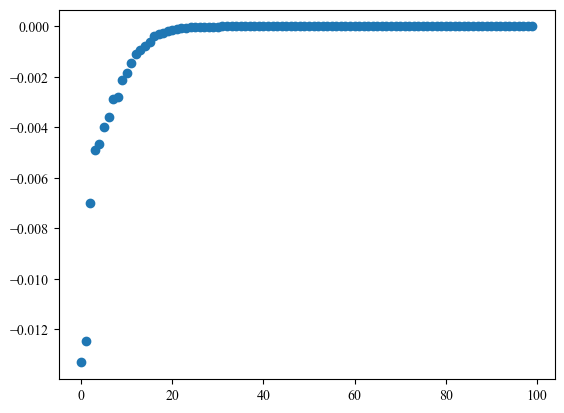

In [58]:
plt.scatter(np.arange(100),ds[:100])

In [56]:
V_1 = np.concatenate((v_shared[:,:5], u1[:,0:1]), axis = 1)
K_V1 = Kernel_matrix(V_1,50)
D_V1 = np.diag(np.sum(K_V1,axis = 1)**(-0.5))
L_V1 = D_V1@K_V1@D_V1

d_V1,v_V1 = np.linalg.eigh(L_V1)
idx_V1 = np.argsort(d_V1)[::-1]
v_V1 = v_V1[:,idx_V1]

K = 10
P_nr = np.eye(L2.shape[0]) - v_V1[:,:K]@v_V1[:,:K].T
L2_nr = P_nr@L2@P_nr
# L2_nr = P_nr@Q2@P_nr

s_nr, u1_nr = np.linalg.eigh(L2_nr)
idx_1_nr = np.argsort(s_nr)[::-1]
u1_nr = u1_nr[:,idx_1_nr]

# s_nr,v2_nr = np.linalg.eigh(L2_nr)
# idx_2_nr = np.argsort(s_nr)[::-1]
# v2_nr = v2_nr[:,idx_2_nr]

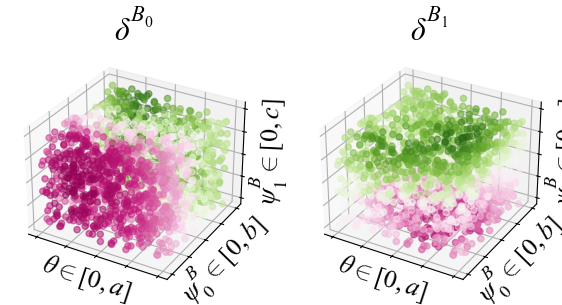

In [71]:
# set up a figure twice as wide as it is tall
fig = plt.figure(figsize=(7,4))

#===============
#  First subplot
#===============

ax = fig.add_subplot(1, 2, 1, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = u1[:,0],alpha=0.55,s=20, cmap='PiYG')
ax.set_title(r"$\delta^{B_0}$", fontsize=23)

#===============
# Second subplot
#===============

ax = fig.add_subplot(1,2, 2, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2], c = u1_nr[:,0],alpha=0.55,s=20, cmap='PiYG')
ax.set_title(r"$\delta^{B_1}$", fontsize=23)


# Labels
x_label = r"$\theta \in [0,a]$"
y_label = r"$\psi^B_0 \in [0,b]$"
z_label = r"$\psi^B_1 \in [0,c]$"

for ax in fig.get_axes():
    ax.set_xlabel(x_label, fontsize=19, labelpad=-10)
    ax.set_ylabel(y_label, fontsize=19, labelpad=-9)
    ax.set_zlabel(z_label, fontsize=19, labelpad=-9)
   
    # Optional: hide ticks if you want
    ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
    


plt.savefig("differential and the itterative differential.pdf",dpi=300) 
plt.show()

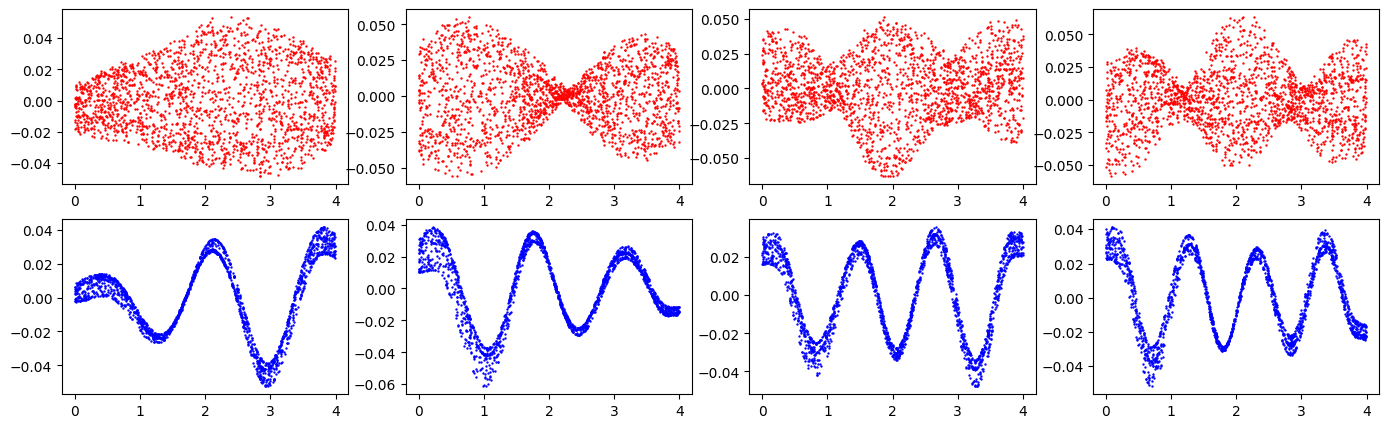

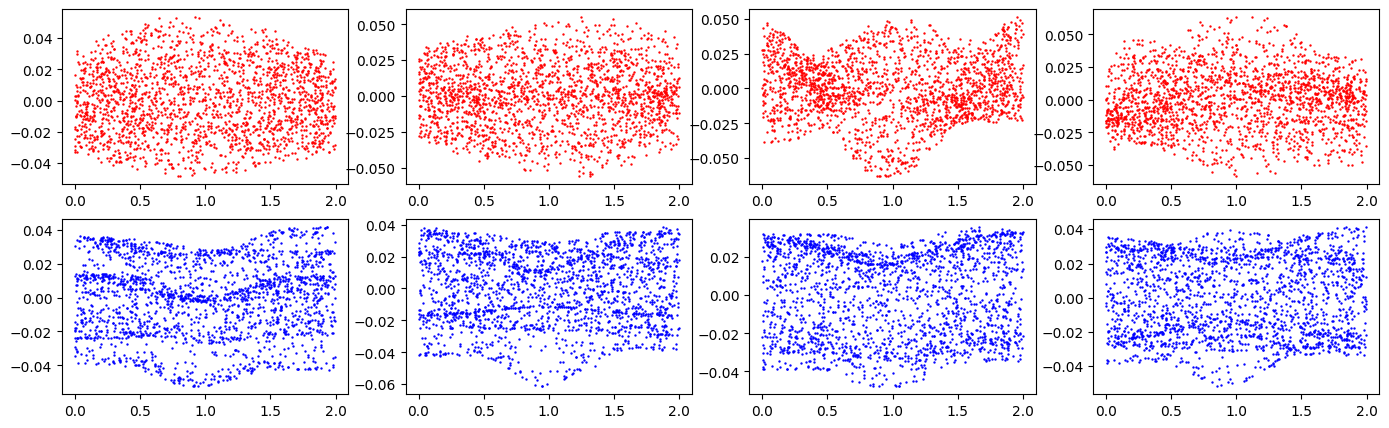

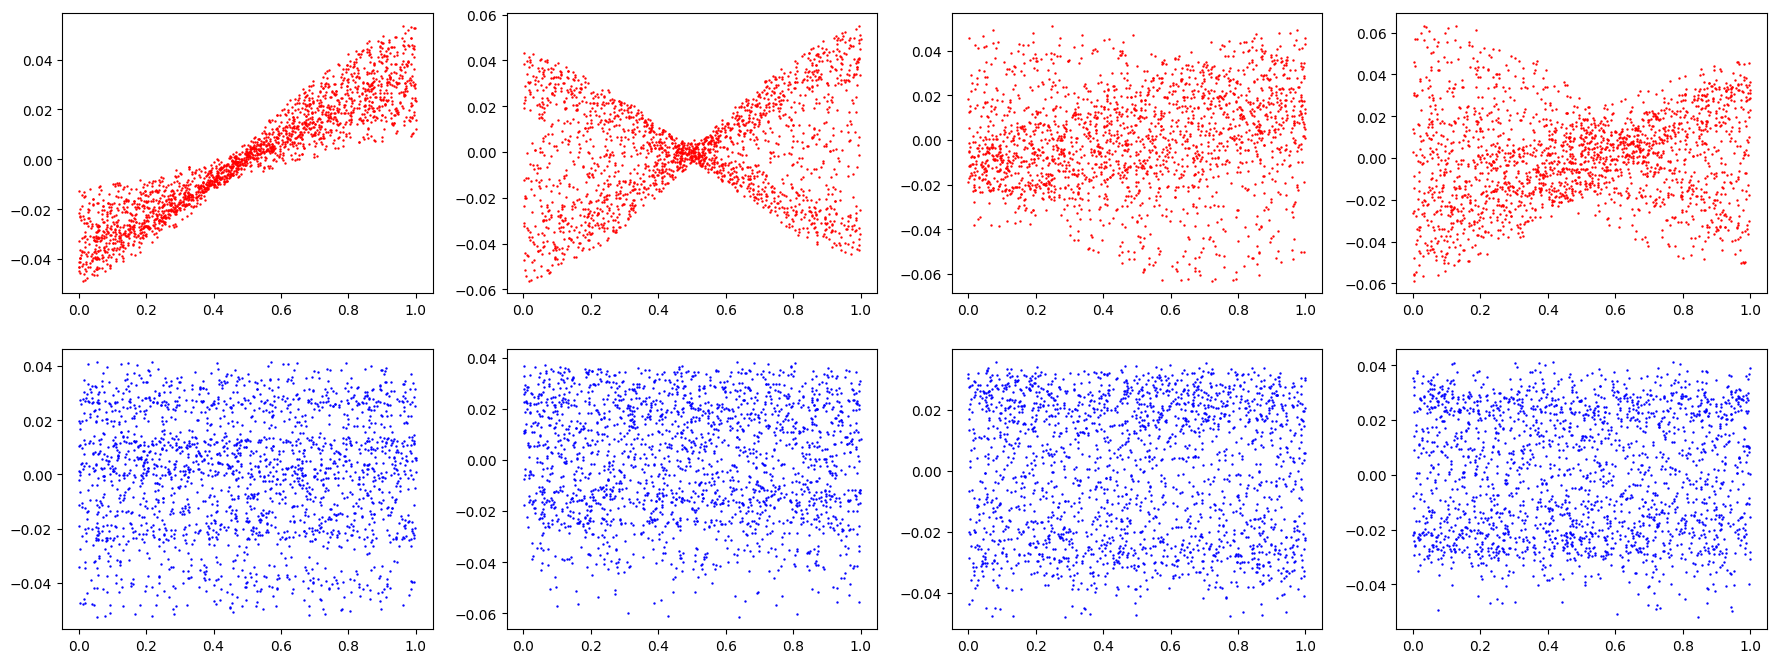

In [18]:
fix, ax = plt.subplots(2,4,figsize = (17,5))
for i in range(4):
    ax[0,i].scatter(w,v1_nr[:,i], s = 0.5, c = 'r')
    ax[1,i].scatter(w,v2_nr[:,i], s = 0.5, c = 'b')

for ax in fig.get_axes():
    ax.label_outer()
    ax.tick_params(axis='both', labelsize=15)
plt.show()

fix,ax = plt.subplots(2,4,figsize = (17,5))
for i in range(4):
    ax[0,i].scatter(l,v1_nr[:,i], s = 0.5, c = 'r')
    ax[1,i].scatter(l,v2_nr[:,i], s = 0.5, c = 'b')
for ax in fig.get_axes():
    ax.label_outer()
    ax.tick_params(axis='both', labelsize=15)

fix, ax = plt.subplots(2,4,figsize = (22,8))
for i in range(4):
    ax[0,i].scatter(h,v1_nr[:,i], s = 0.5, c = 'r')
    ax[1,i].scatter(h,v2_nr[:,i], s = 0.5, c = 'b')

for ax in fig.get_axes():
    ax.label_outer()
    ax.tick_params(axis='both', labelsize=19)
    


In [19]:
v_th_l = np.cos(np.pi*l/L)
v_th_l = v_th_l/np.linalg.norm(v_th_l)
np.max(np.abs(circ_convolution(u1[:,0],v_th_l)))

0.9848532306711222

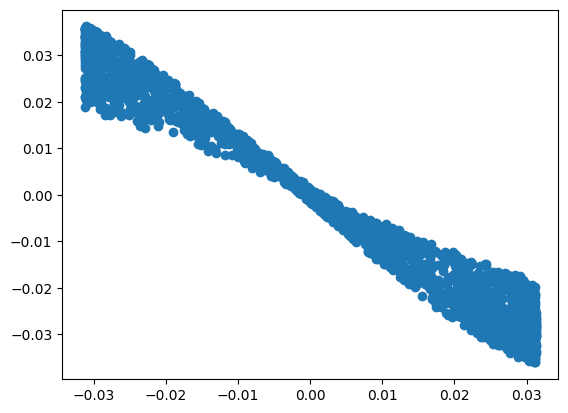

In [20]:
plt.scatter(v_th_l, u1[:,0])

In [21]:
v_th_h = np.cos(np.pi*h/H)
v_th_h = v_th_h/np.linalg.norm(v_th_h)
np.max(np.abs(circ_convolution(v1_nr[:,0],v_th_h)))

0.9434591350709312

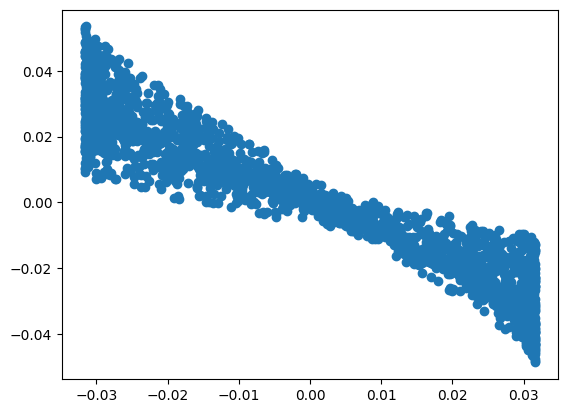

In [22]:
plt.scatter(v_th_h, v1_nr[:,0])

## CCA

In [23]:
n_comps = min(X1.shape[1], X2.shape[1])

cca = CCA(n_components=n_comps)
cca.fit(X1, X2)
X_c, Y_c = cca.transform(X1, X2)

P_c = np.eye(Y_c.shape[0]) - Y_c@np.linalg.inv(Y_c.T@Y_c)@Y_c.T
var_c = P_c@X2
u_cca,d_cca, v_cca = svd(var_c)

vec_cca = np.concatenate((u_cca[:,:2],Y_c), axis=1)
P_c2 = np.eye(vec_cca.shape[0]) - vec_cca@np.linalg.inv(vec_cca.T@vec_cca)@vec_cca.T
var_c2 = P_c2@X2

u_cca2,d_cca2, v_cca2 = svd(var_c2)

In [46]:
v_th_l = np.cos(np.pi*l/L)
v_th_l = v_th_l/np.linalg.norm(v_th_l)
np.max(np.abs(circ_convolution(u_cca[:,1],v_th_l)))

0.9820592261111197

In [47]:
v_th_h = np.cos(np.pi*h/H)
v_th_h = v_th_h/np.linalg.norm(v_th_h)
np.max(np.abs(circ_convolution(u_cca2[:,0],v_th_h)))

0.9848226921823381

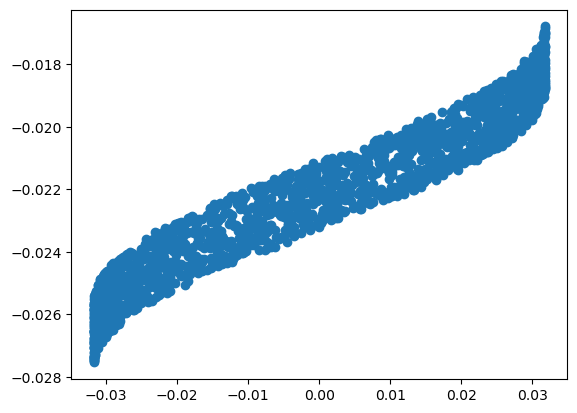

In [48]:
plt.scatter(v_th_l, u_cca[:,0])

In [49]:
v_th_h = np.cos(np.pi*h/H)
v_th_h = v_th_h/np.linalg.norm(v_th_h)
np.max(np.abs(circ_convolution(u_cca[:,0],v_th_h)))

0.05491072050306516

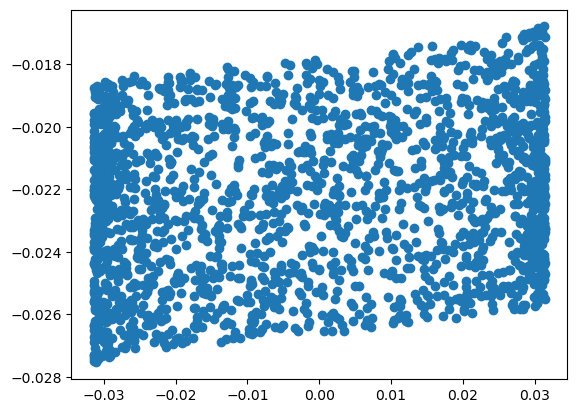

In [50]:
plt.scatter(v_th_h, u_cca[:,0])

### FKT

In [51]:
K1 = Kernel_matrix(X1,350)
K2 = Kernel_matrix(X2,350)

G1 = diags(np.sum(K1, axis=0)) - K1   
G2 = diags(np.sum(K2, axis=0)) - K2   

M1 = G1 + 0.0000001 * np.eye(G1.shape[0])
M2 = G2 + 0.0000001 * np.eye(G2.shape[0])

eval_G1, evec_G1 = np.linalg.eigh(M1)
eval_G2, evec_G2 = np.linalg.eigh(M2)

FK1 = np.linalg.inv(M1+M2)@M1
FK2 = np.linalg.inv(M1+M2)@M2

FK_values_1, eig_vec_FK_1 = eig(FK1)
FK_values_2, eig_vec_FK_2 = eig(FK2)

idx_1 = np.argsort(FK_values_1)[::-1]
eig_vec_FK_1 = eig_vec_FK_1[:,idx_1]

idx_2 = np.argsort(FK_values_2)[::-1]
eig_vec_FK_2 = eig_vec_FK_2[:,idx_2]


In [52]:
FK1_2 = np.linalg.inv(M1+M2)@FK1
FK2_2 = np.linalg.inv(M1+M2)@FK2

FK_values_1_2, eig_FKT_1 = eig(FK1_2)
FK_values_2_2, eig_FKT_2 = eig(FK2_2)

idx_1 = np.argsort(FK_values_1_2)[::-1]
eig_FKT_1 = eig_FKT_1[:,idx_1]

idx_2 = np.argsort(FK_values_2_2)[::-1]
eig_FKT_2 = eig_FKT_2[:,idx_2]


In [343]:
vec_fkt = np.concatenate((eig_vec_FK_2[:,:1], eig_vec_FK_1[:,:1]), axis=1)
P_c_fkt = np.eye(vec_fkt.shape[0]) - vec_fkt@np.linalg.inv(vec_fkt.T@vec_fkt)@vec_fkt.T
var_fkt = P_c_fkt@M2@P_c_fkt
d_fkt,u_fkt = eig(var_fkt)

var_fkt2 = P_c_fkt@FK2@P_c_fkt

d_fkt2,u_fkt2 = eig(var_fkt2)

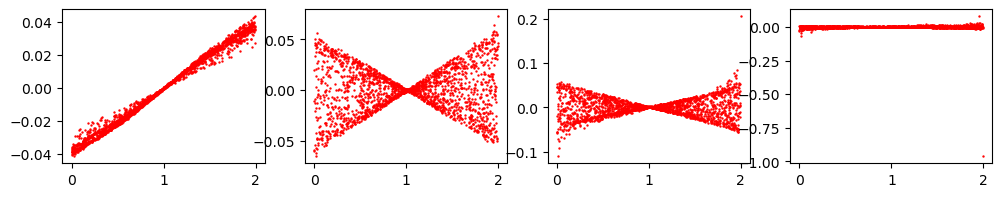

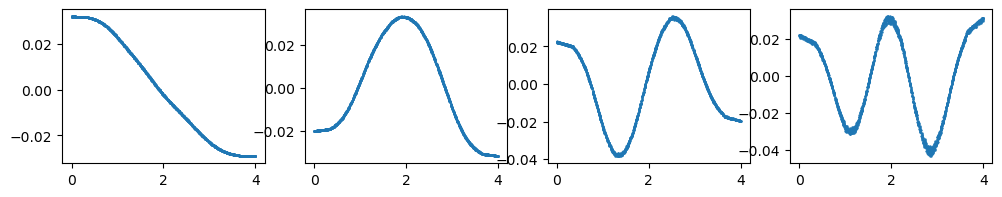

In [338]:
#S_FK = (S_FK)/np.linalg.norm(S_FK)
fig, axs = plt.subplots(1,4, figsize = (12,2))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(l,np.array(eig_vec_FK_1)[:,i], s = 0.5, c = 'r')
    
    

#S_FK = (S_FK)/np.linalg.norm(S_FK)
fig, axs = plt.subplots(1,4, figsize = (12,2))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(w,np.array(eig_vec_FK_2)[:,i], s = 0.5)
    

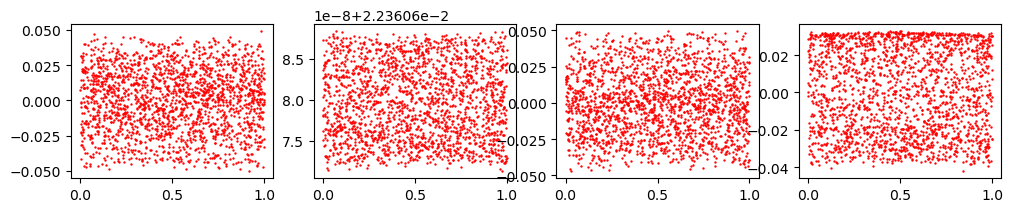

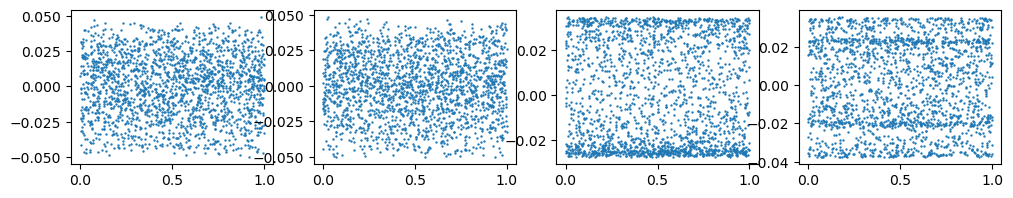

In [344]:
#S_FK = (S_FK)/np.linalg.norm(S_FK)
fig, axs = plt.subplots(1,4, figsize = (12,2))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(h,np.array(u_fkt)[:,i], s = 0.5, c = 'r')
    
    

#S_FK = (S_FK)/np.linalg.norm(S_FK)
fig, axs = plt.subplots(1,4, figsize = (12,2))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(h,np.array(u_fkt2)[:,i], s = 0.5)
    

In [289]:
v_th_l = np.cos(np.pi*l/L)
v_th_l = v_th_l/np.linalg.norm(v_th_l)
np.max(np.abs(circ_convolution(eig_vec_FK_1[:,0],v_th_l)))

0.9915508938967247

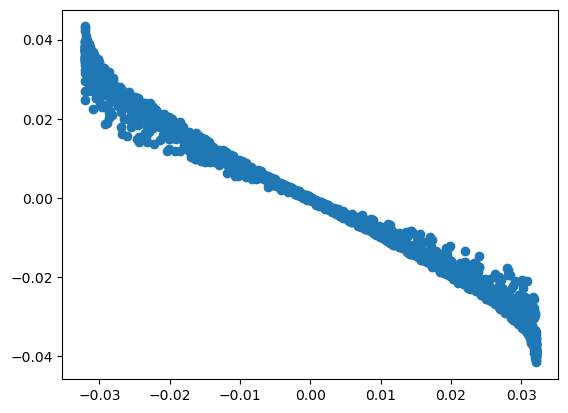

In [290]:
plt.scatter(v_th_l, eig_vec_FK_1[:,0])

In [291]:
u_fkt[:,1].shape

(2000,)

In [328]:
v_th_h = np.cos(np.pi*h/H)
v_th_h = v_th_h/np.linalg.norm(v_th_h)
np.max(np.abs(circ_convolution(u_fkt[:,1],v_th_h)))

0.08287744894351437

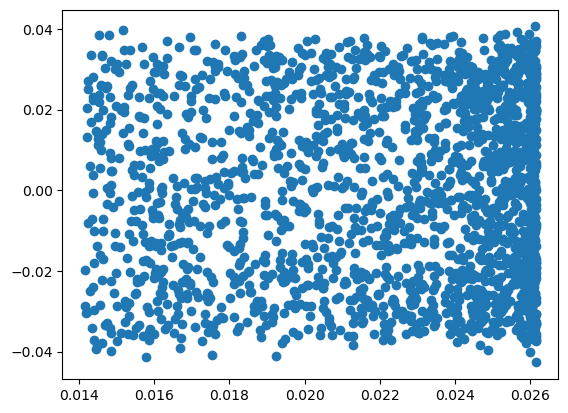

In [156]:
plt.scatter(v_th_h, eig_vec_FK_1[:,0])

### Now N times for different L values:

In [6]:
def squere_corr(W, L, H, N, K = 200, k = 30, sig=0):

    X1 = np.zeros((N,1))
    X2 = np.zeros((N,3))

    w = np.random.uniform(0,W,N)
    l = np.random.uniform(0,L,N)
    h = np.random.uniform(0,H,N)
    h = h[np.argsort(h)]

    X1 = w[np.newaxis].T
    X2 = np.vstack((w, l, h)).T  
    X2 = X2 + np.random.normal(0, sig, X2.shape)

    
    #Differential    
    K1 = Kernel_matrix(X1, K)
    K2 = Kernel_matrix(X2, K)
    
    L1,d1,v1 = LG_sym(K1)
    L2,d2,v2 = LG_sym(K2)

    Q1, s1, u1 = calc_differential_vec(L2,v1,k,"yes")
    Q2, s2, u2 = calc_differential_vec(L1,v2,k, "yes")
  
    v_th_l = np.cos(np.pi*l/L)
    v_th_l  =v_th_l/np.linalg.norm(v_th_l)


    #calc corr for DV 
    corr_DV_L = np.max(np.abs(circ_convolution(u1[:,0],v_th_l)))
    sig_noise_DV_L = calc_sig_to_noise(u1[:,0], l,20, False)
    
    #finding theta
    f_theta = v1[:,:k]@v1[:,:k].T
    L_theta = f_theta @ L2 @ f_theta
    
    s_t, u_theta = np.linalg.eigh(L_theta)
    idx_order_t = np.argsort(s_t)[::-1]
    u_theta = u_theta[:,idx_order_t]
    
    XY = np.concatenate((u_theta[:,1:2], u1[:,0:2]), axis = 1)
    K_XY = Kernel_matrix(XY,50)
    D_XY = np.diag(np.sum(K_XY,axis = 1)**(-0.5))
    L_XY = D_XY@K_XY@D_XY


    d_XY,v_XY = np.linalg.eigh(L_XY)
    idx_1_XY = np.argsort(d_XY)[::-1]
    v_XY = v_XY[:,idx_1_XY]

    L1_nr = np.eye(Q1.shape[0]) - v_XY[:,:3*k]@v_XY[:,:3*k].T
    L1_nr = L1_nr@Q1@L1_nr
    #L2_nr = (np.eye(Q2.shape[0]) - v_XY[:,:K]@v_XY[:,:K].T)@Q2@(np.eye(Q2.shape[0]) - v_XY[:,:K]@v_XY[:,:K].T)


    s_nr,v1_nr = np.linalg.eigh(L1_nr)
    idx_1_nr = np.argsort(s_nr)[::-1]
    v1_nr = v1_nr[:,idx_1_nr]
    
    v_th_h = np.cos(np.pi*h/H)
    v_th_h  =v_th_h/np.linalg.norm(v_th_h)
    
    #calc corr for DV 
    corr_DV_H = np.max(np.abs(circ_convolution(v_th_h, v1_nr[:,1])))
    sig_noise_DV_H = calc_sig_to_noise(v1_nr[:,1], h,20, False)

    #FK transform
    
    G1 = np.diag(np.sum(K1, axis=0)) - K1   
    G2 = np.diag(np.sum(K2, axis=0)) - K2   

    M1 = G1 + 0.0000001 * np.eye(G1.shape[0])
    M2 = G2 + 0.0000001 * np.eye(G2.shape[0])

    eval_G1, evec_G1 = np.linalg.eigh(M1)
    eval_G2, evec_G2 = np.linalg.eigh(M2)

    FK1 = np.linalg.inv(M1+M2)@M1
    FK2 = np.linalg.inv(M1+M2)@M2

    FK_values_1, eig_vec_FK_1 = eig(FK1)
    FK_values_2, eig_vec_FK_2 = eig(FK2)

    idx_1 = np.argsort(FK_values_1)[::-1]
    eig_vec_FK_1 = eig_vec_FK_1[:,idx_1]

    idx_2 = np.argsort(FK_values_2)[::-1]
    eig_vec_FK_2 = eig_vec_FK_2[:,idx_2]
    
    #calc corr for FK
    corr_FK_L = np.max(np.abs(circ_convolution(v_th_l, eig_vec_FK_1[:,0])))
    sig_noise_FK_L = calc_sig_to_noise(eig_vec_FK_1[:,0], l,20, False)
    corr_FK_H = np.max(np.abs(circ_convolution(v_th_h, eig_vec_FK_1[:,0])))
    sig_noise_FK_H = calc_sig_to_noise(eig_vec_FK_1[:,0], h,20, False)

    
     # CCA:
    if X1.shape[1] != X2.shape[1]:
        n_comps = min(X1.shape[1], X2.shape[1])
    else:
        n_comps = X1.shape[1] - 1
    

    cca = CCA(n_components=n_comps)
    cca.fit(X1, X2)
    X_c, Y_c = cca.transform(X1, X2)

    P_c = np.eye(Y_c.shape[0]) - Y_c@np.linalg.inv(Y_c.T@Y_c)@Y_c.T
    var_c = P_c@X2
    var_c = var_c/np.linalg.norm(var_c)
    u_cca,d_cca, v_cca = svd(var_c)
    
    vec_cca = np.concatenate((u_cca[:,:2],Y_c), axis=1)
    P_c2 = np.eye(vec_cca.shape[0]) - vec_cca@np.linalg.inv(vec_cca.T@vec_cca)@vec_cca.T
    var_c2 = P_c2@X2

    u_cca2,d_cca2, v_cca2 = svd(var_c2)
    
    #calc corr for CCA
    corr_CCA_L = np.max(np.abs(circ_convolution(v_th_l, u_cca[:,1])))
    sig_noise_CCA_L = calc_sig_to_noise(u_cca[:,1], l,20, False)
    corr_CCA_H= np.max(np.abs(circ_convolution(v_th_h, u_cca2[:,0])))
    sig_noise_CCA_H = calc_sig_to_noise(u_cca2[:,0], h,20, False)
   
    return corr_DV_L, sig_noise_DV_L, corr_DV_H,sig_noise_DV_H, corr_FK_L,sig_noise_FK_L, corr_FK_H,sig_noise_FK_H,corr_CCA_L,sig_noise_CCA_L, corr_CCA_H,sig_noise_CCA_H     


In [7]:
B = 10
N = 20
acc_squere = np.zeros((B,N,12))

for j in range(B):
    for i in range(N):
        n = 2000
        W = 4 
        L = 2 
        H = 1 
        sig = 0.05*i
        acc_squere[j,i,:] = squere_corr(W,L,H, n, K = 250, k = 3, sig=sig)
        
mean_acc_squere = np.mean(acc_squere,axis=0)

In [31]:
np.save("Cube_simulation",acc_squere)

In [4]:
acc_squere = np.load("Cube_simulation.npy")
mean_acc_squere = np.mean(acc_squere,axis=0)


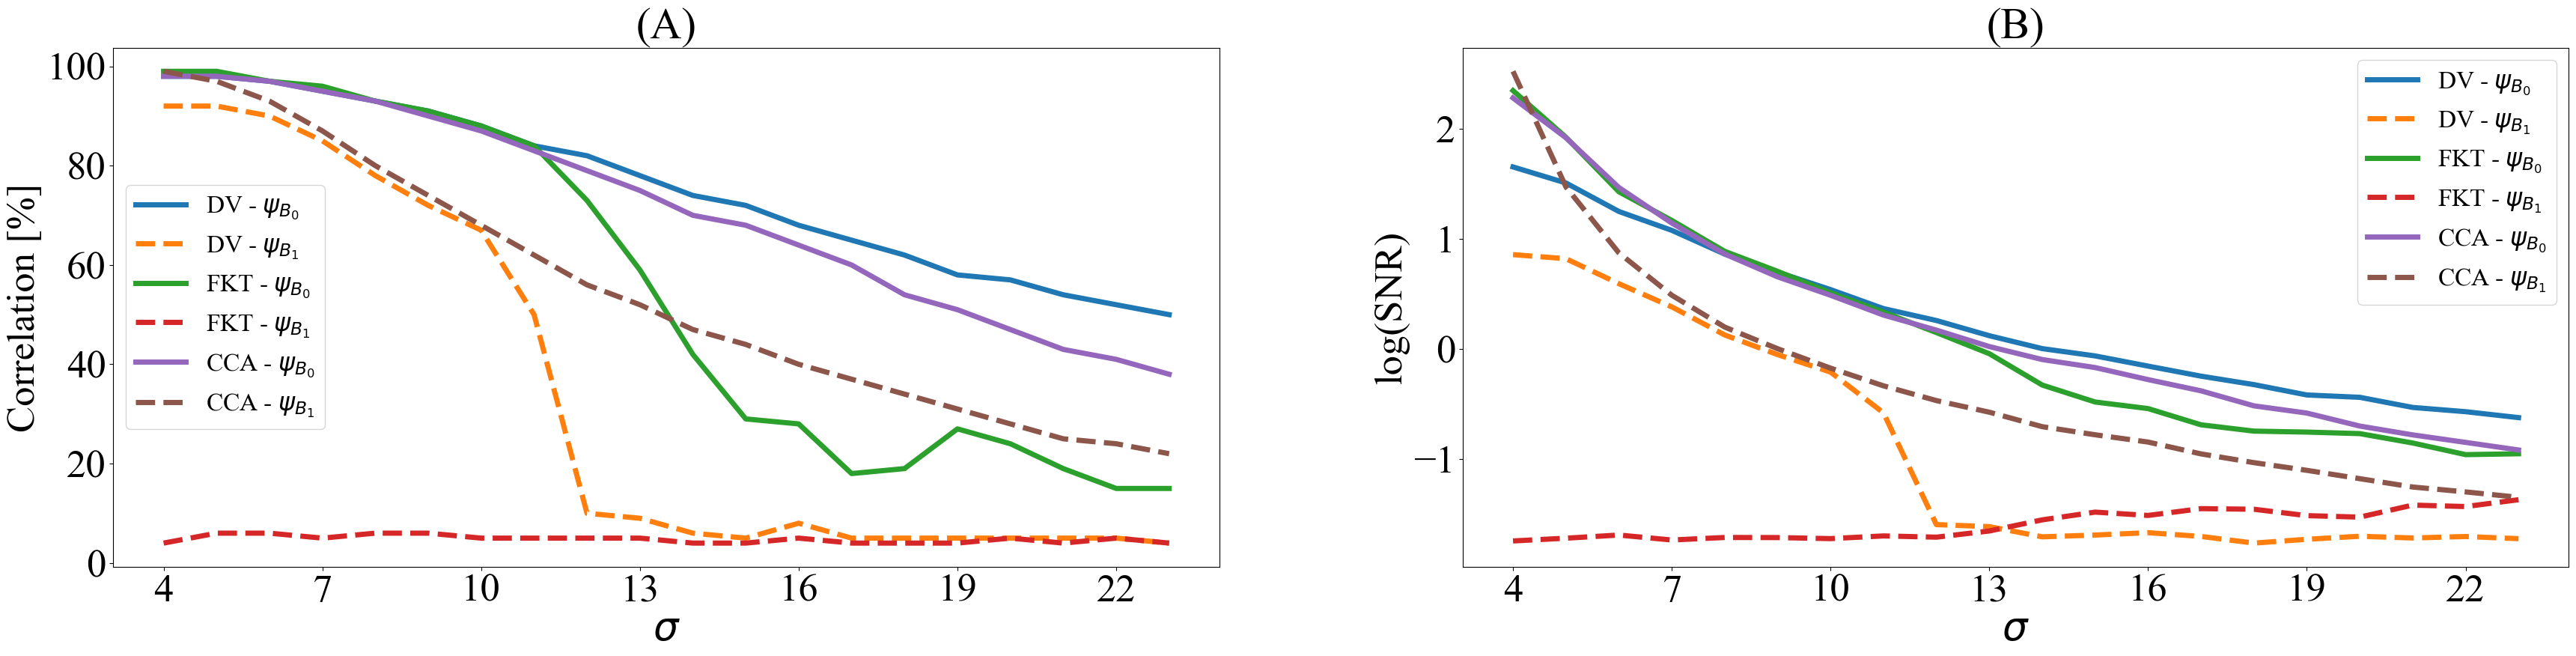

In [21]:
N=20
font = font_manager.FontProperties(family='Times New Roman',size=24)

# Set up a figure twice as tall as it is wide
fig = plt.figure(figsize=(32,9))
plt.subplots_adjust(right=1.15)
plt.subplots_adjust(wspace=0.22)

# # First subplot
# ax = fig.add_subplot(1,4, 1)

# ax.scatter(X1, np.tile(([0]),2000), s = 3)
# ax.set_title("(A)", fontsize = 42, **csfont)
# plt.xticks(np.arange(0,5,1),fontsize=34, rotation = 0, **csfont)
# plt.yticks(fontsize=34, rotation = 0, **csfont)
# ax.tick_params(left = False, right = False , labelleft = False ,
#                 labelbottom = False, bottom = False)


# # Second subplot
# ax = fig.add_subplot(1,4,2, projection='3d')


# surf = ax.scatter(X2[:,0], X2[:,1], X2[:,2],s=3)
# ax.set_title("(B)", fontsize = 42, **csfont)
# plt.xticks(np.arange(0,5,1),fontsize=34, rotation = 0, **csfont)
# plt.yticks(np.arange(0,3,1),fontsize=34, rotation = 0, **csfont)
# for t in ax.zaxis.get_major_ticks(): t.label.set_fontsize(28)
# for t in ax.zaxis.get_major_ticks(): t.label.set_fontname('Times New Roman')
# ax.view_init(10, 60)
# ax.tick_params(left = False, right = False , labelleft = False ,
#                 labelbottom = False, bottom = False)


# Third subplot
ax = fig.add_subplot(1,2,1)

ax.plot(np.arange(4,N+4),np.round(100*mean_acc_squere[:,0]), label = 'DV - $\psi_{B_0}$',linewidth=5)
ax.plot(np.arange(4,N+4),np.round(100*mean_acc_squere[:,2]), label = 'DV - $\psi_{B_1}$',linewidth=5, linestyle='--')
ax.plot(np.arange(4,N+4),np.round(100*mean_acc_squere[:,4]), label = 'FKT - $\psi_{B_0}$',linewidth=5)
ax.plot(np.arange(4,N+4),np.round(100*mean_acc_squere[:,6]), label = 'FKT - $\psi_{B_1}$',linewidth=5, linestyle='--')
ax.plot(np.arange(4,N+4),np.round(100*mean_acc_squere[:,8]), label = 'CCA - $\psi_{B_0}$',linewidth=5)
ax.plot(np.arange(4,N+4),np.round(100*mean_acc_squere[:,10]), label = 'CCA - $\psi_{B_1}$',linewidth=5, linestyle='--')

ax.set_ylabel("Correlation [%]", fontsize = 38, **csfont)#with cos($\pi {\psi_B}_0/b$) \n and cos($\pi {\psi_B}_1/c$) 
ax.set_xlabel("$\sigma$", fontsize = 38, **csfont)
ax.set_title("(A)", fontsize = 42, **csfont)
plt.xticks(np.arange(4,N+4,3),fontsize=38, rotation = 0, **csfont)
plt.yticks(fontsize=38, rotation = 0, **csfont)
plt.legend( prop=font)

#Fourth subplot
ax = fig.add_subplot(1,2,2)

ax.plot(np.arange(4,N+4),np.log(mean_acc_squere[:,1]), label = 'DV - $\psi_{B_0}$',linewidth=5)
ax.plot(np.arange(4,N+4),np.log(mean_acc_squere[:,3]), label = 'DV - $\psi_{B_1}$',linewidth=5, linestyle='--')
ax.plot(np.arange(4,N+4),np.log(mean_acc_squere[:,5]), label = 'FKT - $\psi_{B_0}$',linewidth=5)
ax.plot(np.arange(4,N+4),np.log(mean_acc_squere[:,7]), label = 'FKT - $\psi_{B_1}$',linewidth=5, linestyle='--')
ax.plot(np.arange(4,N+4),np.log(mean_acc_squere[:,9]), label = 'CCA - $\psi_{B_0}$',linewidth=5)
ax.plot(np.arange(4,N+4),np.log(mean_acc_squere[:,11]), label = 'CCA - $\psi_{B_1}$',linewidth=5, linestyle='--')

ax.set_ylabel("log(SNR)", fontsize = 38, **csfont)
ax.set_xlabel("$\sigma$", fontsize = 38, **csfont)
ax.set_title("(B)", fontsize = 42, **csfont)
plt.xticks(np.arange(4,N+4,3),fontsize=38, rotation = 0, **csfont)
plt.yticks(fontsize=38, rotation = 0, **csfont)
plt.legend(prop=font)

txt="(a) the Line. (b) The rectangle. (c) blue - the correlation between the Differential vectors and the cosine of 'l'. orange - the correlation between the FKT eigenvectors and \n the cosine of the angle 't'."
# center text
#fig.text(.5, -.25, txt, ha='center', fontsize = 16)
fig.savefig("Squere panel.pdf", dpi = 100,bbox_inches='tight')
plt.show()